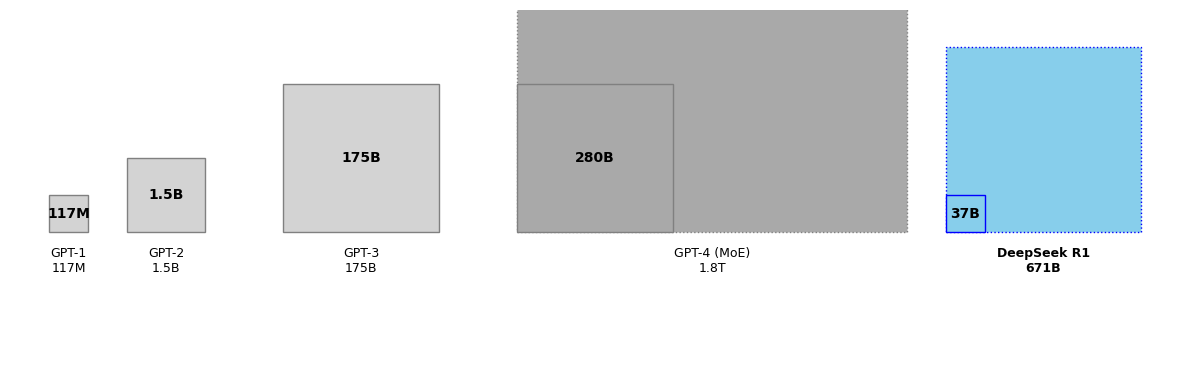

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Unified model list with color settings and standardized active param labels
models = [
    {'name': 'GPT-1\n117M', 'total': 0.5, 'active': 0.5, 'x': 0.5, 'color': 'lightgray', 'edge': 'gray', 'active_label': '117M'},
    {'name': 'GPT-2\n1.5B', 'total': 1, 'active': 1, 'x': 1.5, 'color': 'lightgray', 'edge': 'gray', 'active_label': '1.5B'},
    {'name': 'GPT-3\n175B', 'total': 2, 'active': 2, 'x': 3.5, 'color': 'lightgray', 'edge': 'gray', 'active_label': '175B'},
    {'name': 'GPT-4 (MoE)\n1.8T', 'total': 5, 'active': 2, 'x': 6.5,
     'color': 'darkgray', 'edge': 'gray', 'outer_style': 'dotted', 'active_label': '280B'},
    {'name': 'DeepSeek R1\n671B', 'total': 2.5, 'active': 0.5, 'x': 12.0,
     'color': 'skyblue', 'edge': 'blue', 'outer_style': 'dotted', 'active_label': '37B', 'text_color': 'blue'}
]

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 15)
ax.set_ylim(0, 5)
ax.axis('off')

# Common vertical position for all rectangles
y_pos = 2

# Draw models
for model in models:
    # Draw outer box if total != active
    if model['total'] != model['active']:
        outer_rect = patches.Rectangle(
            xy=(model['x'], y_pos),
            width=model['total'], height=model['total'],
            linewidth=1, edgecolor=model['edge'],
            facecolor=model['color'],
            linestyle=model.get('outer_style', 'solid')
        )
        ax.add_patch(outer_rect)

    # Draw active params box
    active_rect = patches.Rectangle((model['x'], y_pos), model['active'], model['active'],
                                    linewidth=1, edgecolor=model['edge'], facecolor=model['color'])
    ax.add_patch(active_rect)

    # Label below the model
    ax.text(model['x'] + model['total'] / 2, y_pos - 0.2, model['name'],
            ha='center', va='top', fontsize=9, fontweight='bold' if 'DeepSeek' in model['name'] else 'normal')

    # Active parameter label inside the active box
    ax.text(model['x'] + model['active'] / 2, y_pos + model['active'] / 2, model['active_label'],
            ha='center', va='center', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()


In [15]:
import pandas as pd

data = {
    'Model': ['DeepSeek-V3', 'GPT-4 (est.)', 'LLaMA-3 (70B)'],
    'GPU Type': ['H800', 'H100', 'A100'],
    'Number of GPUs Used': [2048, 10000, 2500],
    'Estimated GPU Hours': ['2.79M', '30.00M', '7.00M'],
    'Training Duration (Days)': [60, 90, 45],
    'GPU Hourly Rental (USD)': [2.0, 3.0, 1.5],
    'Estimated $ Cost (USD)': ['$5.58M', '$90.00M', '$10.50M']
}

df = pd.DataFrame(data)
print('Training cost:')
df

Training cost:


,Model,GPU Type,Number of GPUs Used,Estimated GPU Hours,Training Duration (Days),GPU Hourly Rental (USD),Estimated $ Cost (USD)
0,DeepSeek-V3,H800,2048,2.79M,60,2.0,$5.58M
1,GPT-4 (est.),H100,10000,30.00M,90,3.0,$90.00M
2,LLaMA-3 (70B),A100,2500,7.00M,45,1.5,$10.50M


In [16]:
import pandas as pd
data_metrics = {
    "Metric": [
        "Tokens",
        "Words (approx.)",
        "Characters (raw)",
        "Uncompressed size"
    ],
    "Estimate": [
        "14.8 trillion",
        "~10 trillion",
        "~50 trillion",
        "~50 TB"
    ]
}

df_metrics = pd.DataFrame(data_metrics)
print('Training dataset:')
display(df_metrics)
print("""
for comparison:
GPT-3 used 300B tokens, ~570 GB uncompressed.
DeepSeek-V3 used 14.8T tokens → nearly 50× the GPT-3 dataset
""")

Training dataset:


,Metric,Estimate
0,Tokens,14.8 trillion
1,Words (approx.),~10 trillion
2,Characters (raw),~50 trillion
3,Uncompressed size,~50 TB



for comparison:
GPT-3 used 300B tokens, ~570 GB uncompressed.
DeepSeek-V3 used 14.8T tokens → nearly 50× the GPT-3 dataset



In [2]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

data_features = {
    'Feature': [
        'BPE (byte-pair encoding)',
        'Byte-level BPE',
        'Vocabulary Size'
    ],
    'Explanation': [
        'Tokenizer that merges common symbol pairs into subwords or words',
        'Uses raw bytes as the base, improving robustness across languages/scripts',
        '128,000 tokens, larger than typical models, allowing richer encoding'
    ]
}

print('Vocabulary size:')
df_features = pd.DataFrame(data_features)
display(df_features)
print('''
for comparison:
most models use 32K–50K tokens (e.g., GPT-2 uses ~50K, LLaMA-2 uses 32K). So 128K is notably expanded
''')

Vocabulary size:


,Feature,Explanation
0,BPE (byte-pair encoding),Tokenizer that merges common symbol pairs into subwords or words
1,Byte-level BPE,"Uses raw bytes as the base, improving robustness across languages/scripts"
2,Vocabulary Size,"128,000 tokens, larger than typical models, allowing richer encoding"



for comparison:
most models use 32K–50K tokens (e.g., GPT-2 uses ~50K, LLaMA-2 uses 32K). So 128K is notably expanded



In [11]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

data_hparams = {
    'Hyper-Parameter': [
        'Number of Transformer layers',
        'Hidden dimension',
        'Attention heads (nₕ)',
        'Per-head dimension (dₕ)',
        'Feedforward layers',
        'MoE experts per layer',
        'MoE expert hidden dimension',
        'MoE experts activated per token',
        'Max nodes per token',
        'Multi-token prediction depth (𝐷)',
        'Normalization',
        'Scaling',
        'Total parameters',
        'Activated parameters per token',
        'Context Window Size'
    ],
    'DeepSeek-V3': [
        '61',
        '7168',
        '128',
        '128',
        'First 3 FFN, rest MoE',
        '1 shared + 256 routed',
        '2048',
        '8',
        '4',
        '1',
        'RMSNorm after compressed latent vectors',
        'Scaling at width bottlenecks',
        '671B',
        '37B',
        '128K tokens'
    ],
    'GPT-4 (est. 2024)': [
        'Unknown (likely ~96)',
        '12288',
        '96',
        '128',
        'Mostly FFN, sparse MoE in some variants',
        '16 experts (GPT-4 MoE variant est.)',
        '8192',
        '2',
        'Unknown',
        'Possibly >1',
        'RMSNorm',
        'Yes',
        '1.76T (full), ~560B (dense), ~1.76T (MoE)',
        '1.76T (full), ~560B (dense), ~280B (MoE)',
        "8K–128K tokens\n(GPT-4 public version typically supports 8K or 32K,\nwhile GPT-4-turbo extends to 128K.\n Exact training context not confirmed.)"
    ],
    'LLaMA-3 (70B)': [
        '80',
        '8192',
        '64',
        '128',
        'Standard FFN',
        'N/A',
        '14336',
        'N/A',
        'N/A',
        '1',
        'RMSNorm',
        'Yes',
        '70B',
        '70B',
        '8K tokens'
    ]
}

df_hparams = pd.DataFrame(data_hparams)
print('Hyperparameters:')
display(df_hparams.style.set_properties(**{
    'white-space': 'pre-wrap'
}))

Hyperparameters:


,Hyper-Parameter,DeepSeek-V3,GPT-4 (est. 2024),LLaMA-3 (70B)
0,Number of Transformer layers,61,Unknown (likely ~96),80
1,Hidden dimension,7168,12288,8192
2,Attention heads (nₕ),128,96,64
3,Per-head dimension (dₕ),128,128,128
4,Feedforward layers,"First 3 FFN, rest MoE","Mostly FFN, sparse MoE in some variants",Standard FFN
5,MoE experts per layer,1 shared + 256 routed,16 experts (GPT-4 MoE variant est.),N/A
6,MoE expert hidden dimension,2048,8192,14336
7,MoE experts activated per token,8,2,N/A
8,Max nodes per token,4,Unknown,N/A
9,Multi-token prediction depth (𝐷),1,Possibly >1,1


Hardware architecture:
* 64 GPUs per PP Stage (pipeline parallelism)
* 5120 GB VRAM per PP Stage
* 16 PP Stages per ZeRO-1 (data parallelism) replica: 1024 GPUs, 81920 GB VRAM

![Hardware architecture](./static/deepseek-v3-r1/deepseek-v3-r1-hardware-architecture.png)


20 of 132 Streaming Multiprocessors (SM) are allocated to support DualPipe routing

![Communication footprint](./static/deepseek-v3-r1/deepseek-v3-r1-hardware-communication-cost.png)

Software Architecture of a single Transformer Block

![Software Architecture](./static/deepseek-v3-r1/deepseek-v3-r1-software-architecture-transformer-block.png)

Software Architecture:
* 61 transformer blocks broken into 16 stages, where 00 carries `embeddings` and `output head` and the 01-15 carry Transformer Blocks

![Software Architecture](./static/deepseek-v3-r1/deepseek-v3-r1-software-architecture.png)

Multi-token Prediction module in details:

![Multi-Token Prediction](./static/deepseek-v3-r1/deepseek-v3-r1-mtp-software-architecture.png)


Optimizations:
* FP8 Training
* Low-rank compression for attention keys, queues values to reduce Key-Value (KV) cache and activation memory